# Exposure and Use effects

Given the previous exploration of response distribution by proficiency level, and given that perceived level offered a clearer picture than objective level, looking into the difference in exposure to the L2 is what seems we need to look into next as formal proficiency alone does not explain restructuring.

A repeated meaningful communicative environment could give some light on whether transfer resolution stabilizes or persists. In this sense, professional need could be adding pressure to the learner and this could lead to improving their theoretical knowledge of the L2; however, professional use entails and actual procedural engagement with the L2.

1. Previous cleaning steps
2. Map labels to professional need and professional use
3. Merge data and cleaning/ validation steps
4. Counts and proportions by professional need
5. Counts and proportions by professional use
6. Inspect potential subgroup distribution

Import necessary libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read datasets

In [33]:
responses = pd.read_csv("../../data/raw/counterfactual_responses_raw.csv")
metadata = pd.read_csv("../../data/raw/metadata_raw.csv")

## 1. Previous cleaning steps

Response data cleaning steps

In [34]:
responses = responses.rename(
    columns={"Partcipant_ID": "Participant_ID"}
)

responses["Response"] = (
    responses["Response"]
    .str.strip()
)

responses.shape

(336, 9)

Metadata cleaning steps

In [35]:
metadata.columns = metadata.columns.str.strip()

metadata = metadata.drop(columns = ["Agent"])

metadata.shape

(56, 18)

## 2. Map labels to professional need and professional use

Add professional need and professional use labels in metadata

In [36]:
prof_mapping = {
    0: "No",
    1: "Yes"
}

metadata["Prof_Need_Label"] = (
    metadata["Prof_Need"]
    .map(prof_mapping)
)

metadata["Prof_Use_Label"] = (
    metadata["Prof_Use"]
    .map(prof_mapping)
)

In [37]:
metadata.shape

(56, 20)

## 3. Merge data and cleaning/ validation steps

Merge datasets and check null values

In [38]:
merged_data = responses.merge(
    metadata,
    on= "Participant_ID",
    how="left"
)

In [39]:
merged_data.head()

,Participant_ID,Focus,Agent,Goal_Type,Item,Item_string,Item_len,Response_tag,Response,EXP,...,Multi_Spk,Immersion,Prof_Need,Prof_Use,Motivation,Distractor,GN_Score,Difficulty,Prof_Need_Label,Prof_Use_Label
0,EXP1_01,I,1,no_goal,Item1,"""If I had heard the rainstorm, I would have fe...",11,L1_transfer_3,L1_transfer,1,...,1,0,1,1,4,4,23,3,Yes,Yes
1,EXP1_01,I,1,no_goal,Item2,"""If I had climbed the mountain cliff, I would ...",12,L1_transfer_3,L1_transfer,1,...,1,0,1,1,4,4,23,3,Yes,Yes
2,EXP1_01,I,1,goal_non_frequent,Item1,"""If I had created an online platform, I would ...",14,L1_transfer_3,L1_transfer,1,...,1,0,1,1,4,4,23,3,Yes,Yes
3,EXP1_01,I,1,goal_non_frequent,Item2,"""If I had invested in technology, I would have...",13,correct_3,correct,1,...,1,0,1,1,4,4,23,3,Yes,Yes
4,EXP1_01,I,1,goal_frequent,Item1,"""If I had saved money, I would have gone on ho...",11,correct_3,correct,1,...,1,0,1,1,4,4,23,3,Yes,Yes


In [40]:
merged_data.shape

(336, 28)

In [41]:
merged_data.isnull().sum()

Participant_ID      0
Focus               0
Agent               0
Goal_Type           0
Item                0
Item_string         0
Item_len            0
Response_tag       11
Response           11
EXP                 0
n                   0
Age                 0
Gender              0
Kno_Level           0
Per_Level           0
Bilingual           0
Bi_Parents          0
Multi_Kno           0
Multi_Spk           0
Immersion           0
Prof_Need           0
Prof_Use            0
Motivation          0
Distractor          0
GN_Score            0
Difficulty          0
Prof_Need_Label     0
Prof_Use_Label      0
dtype: int64

In [42]:
merged_data.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'EXP', 'n', 'Age', 'Gender',
       'Kno_Level', 'Per_Level', 'Bilingual', 'Bi_Parents', 'Multi_Kno',
       'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use', 'Motivation',
       'Distractor', 'GN_Score', 'Difficulty', 'Prof_Need_Label',
       'Prof_Use_Label'],
      dtype='str')

In [43]:
merged_data[["Prof_Need", "Prof_Need_Label", "Prof_Use", "Prof_Use_Label"]].head(10)

,Prof_Need,Prof_Need_Label,Prof_Use,Prof_Use_Label
0,1,Yes,1,Yes
1,1,Yes,1,Yes
2,1,Yes,1,Yes
3,1,Yes,1,Yes
4,1,Yes,1,Yes
5,1,Yes,1,Yes
6,0,No,0,No
7,0,No,0,No
8,0,No,0,No
9,0,No,0,No


Convert nulls into explicit label temporarily

In [44]:
merged_data["Response_Full"] = (
    merged_data["Response"]
    .fillna("null")
)

## 4. Counts and proportions by professional need

Counts and Proportions of Responses by Professional Need

In [45]:
pd.crosstab(
    merged_data["Prof_Need_Label"],
    merged_data["Response_Full"],
    margins= True
)

Response_Full,L1_transfer,L2_other,correct,null,All
Prof_Need_Label,,,,,
No,16,9,21,2,48
Yes,133,63,83,9,288
All,149,72,104,11,336


In [46]:
prof_need_response_props = pd.crosstab(
    merged_data["Prof_Need_Label"],
    merged_data["Response_Full"],
    normalize= "index"
)

prof_need_response_props

Response_Full,L1_transfer,L2_other,correct,null
Prof_Need_Label,,,,
No,0.333333,0.18750,0.437500,0.041667
Yes,0.461806,0.21875,0.288194,0.031250


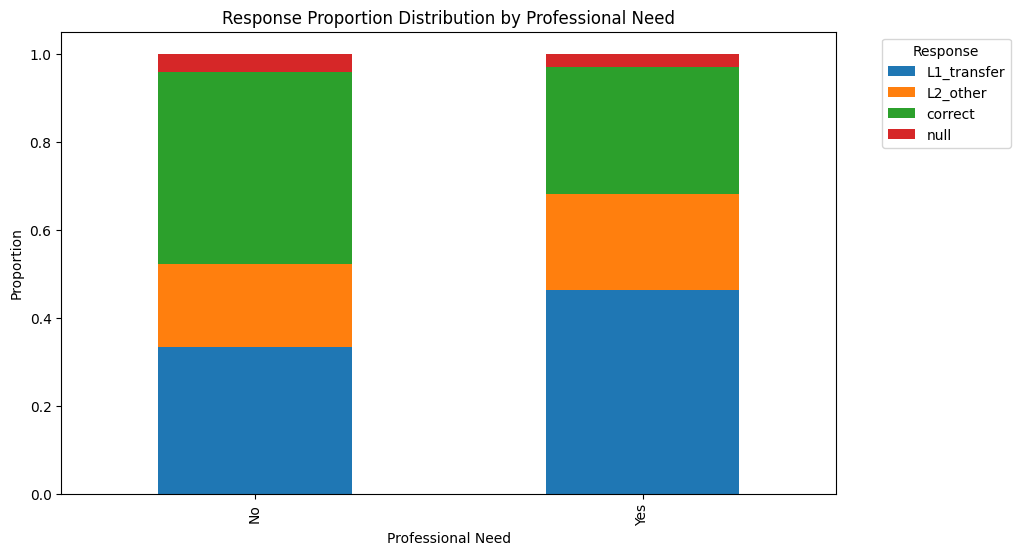

In [47]:
prof_need_response_props.plot(kind="bar", stacked=True, figsize= (10,6))

plt.title("Response Proportion Distribution by Professional Need")
plt.xlabel("Professional Need")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()

Interestingly, one might originally expect that needing L2-English professionally may lead to a better target performance just by adding pressure. Yet, this is not what the distribution shows. 

Fewer correct resolution and increased transfer shows that needing L2-English does not necessarily mean a stable, procedural control of complex structures; that is, if transfer successfully manages to communicate meaning in real life, the system may actually reinforce it. 

## 5. Counts and proportions by professional use

Counts and Proportions of Responses by Professional Use

In [48]:
pd.crosstab(
    merged_data["Prof_Use_Label"],
    merged_data["Response_Full"],
    margins= True
)

Response_Full,L1_transfer,L2_other,correct,null,All
Prof_Use_Label,,,,,
No,49,31,34,6,120
Yes,100,41,70,5,216
All,149,72,104,11,336


In [49]:
prof_use_response_props = pd.crosstab(
    merged_data["Prof_Use_Label"],
    merged_data["Response_Full"],
    normalize= "index"
)

prof_use_response_props

Response_Full,L1_transfer,L2_other,correct,null
Prof_Use_Label,,,,
No,0.408333,0.258333,0.283333,0.050000
Yes,0.462963,0.189815,0.324074,0.023148


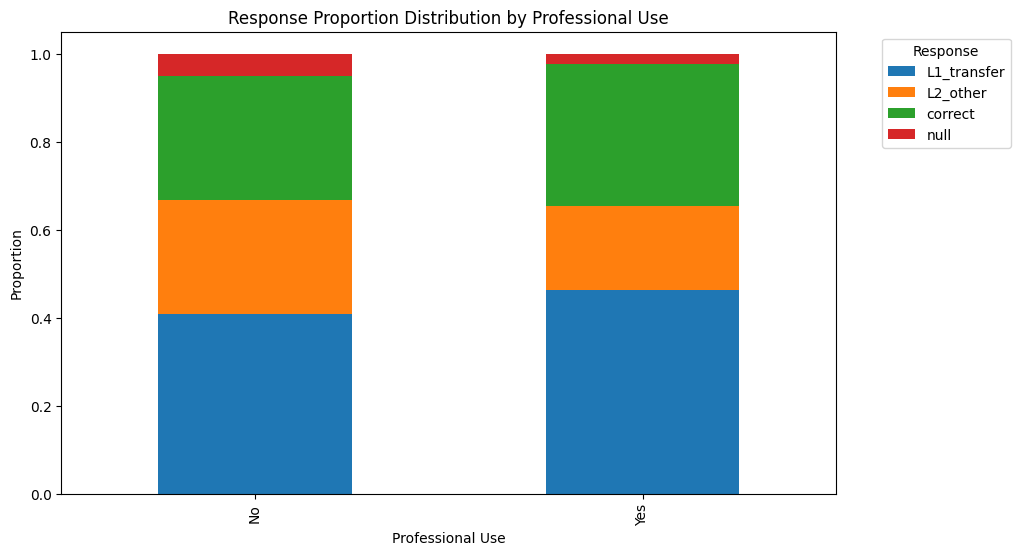

In [50]:
prof_use_response_props.plot(kind="bar", stacked=True, figsize= (10,6))

plt.title("Response Proportion Distribution by Professional Use")
plt.xlabel("Professional Use")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()

Professional use (and not only need) could be forcing resolution by either using the correct structure or by means of transfer; this is shown by the fact that both correct and transfer responses increase. What is interesting is that participants are less likely to remain in the L2-alternative space which is shown by a decrease of L2_other responses. 

This reinforces the idea that transfer is not just an error but either a processing strategy, a stable fallback mapping like a learnt path, a competing representational system under excesive cognitive load or similar.

## 6. Inspect potential subgroup distribution

Given the previous findings, this inspects a potential subgroup distribution to see how proficiency (perceived level = B1.2, B2.1, B2.2 and C1) and exposure (professional use = Yes) relates to response behaviour in further exploratory analyses.

Include Per_Level_Labels from B1.2 to C1 in the subset

In [51]:
level_mapping = {
    1: "A1",
    2: "A2.1",
    3: "A2.2",
    4: "B1.1",
    5: "B1.2",
    6: "B2.1",
    7: "B2.2",
    8: "C1",
    9: "C2"
}

merged_data["Per_Level_Label"] = (
    merged_data["Per_Level"]
    .map(level_mapping)
)

level_order = [
    "A1",
    "A2.1",
    "A2.2",
    "B1.1",
    "B1.2",
    "B2.1",
    "B2.2",
    "C1",
    "C2"
]

merged_data["Per_Level_Label"] = pd.Categorical(
    merged_data["Per_Level_Label"],
    categories=level_order,
    ordered=True
)


subset = merged_data[
    merged_data["Per_Level_Label"].isin(
        ["B1.2", "B2.1", "B2.2", "C1"]
    )
]


In [52]:
subset.shape

(330, 30)

In [53]:
pd.crosstab(
    subset["Per_Level_Label"],
    subset["Prof_Use_Label"],
    margins= True
)

Prof_Use_Label,No,Yes,All
Per_Level_Label,,,
B1.2,30,12,42
B2.1,12,54,66
B2.2,72,90,162
C1,6,54,60
All,120,210,330


In [54]:
subset_props =pd.crosstab(
    subset["Per_Level_Label"],
    subset["Prof_Use_Label"],
    normalize="index"
)

subset_props

Prof_Use_Label,No,Yes
Per_Level_Label,,
B1.2,0.714286,0.285714
B2.1,0.181818,0.818182
B2.2,0.444444,0.555556
C1,0.100000,0.900000


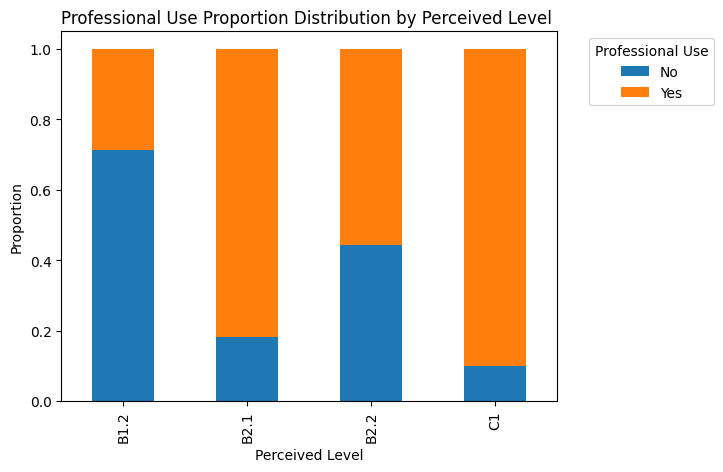

In [56]:
subset_props.plot(kind = "bar", stacked = True)

plt.title("Professional Use Proportion Distribution by Perceived Level ")
plt.xlabel("Perceived Level")
plt.ylabel("Proportion")
plt.legend(title = "Professional Use", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()

What we can see is that perceived advanced proficiency overlaps with professional use strongly. Interestingly, then, the increase in transfer with perceived level is also linked to communicative deployment. 

This also shows that the ideal target population for futher analyses and modeling is B2.1 to C1: it will reduce irrelevant variance from low proficient and less stabilized users while focusing on those that actively deploy English by engaging in real-time commmunication and who are meant to objectively have studied and know the rule. 